# Analyzing the weekday increment operator on a templated dataset

In [1]:
# Notebook setup
%cd /home/can/feature_zoo/
%load_ext autoreload
%autoreload 2

/home/can/feature_zoo


In [2]:
# Initialize Experiment config (defines dataset, model, sae)

from src.config import load_config

cfg = load_config(overrides=[
    # "llm=gpt2",
    # "llm=llama3.1-8b-base",
    "llm=olmo3-32b-base",
    "data=days_trajectories"
])

In [4]:
from src.cache_llm import load_short_trajectory_acts
import torch as th
import numpy as np
import matplotlib.pyplot as plt
import einops

return_dict = load_short_trajectory_acts(cfg, force_recompute=True)

def to_numpy(t: th.Tensor) -> np.ndarray:
    return t.detach().cpu().float().numpy()

labels = return_dict["labels"]
texts = return_dict["texts"]
input_ids_BT = return_dict["input_ids_BT"]
llm_BWD = to_numpy(return_dict["llm_BWD"])
llm_BWD.shape

LLM Cache:   0%|          | 0/87 [00:00<?, ?it/s]/home/can/feature_zoo/.venv/lib/python3.12/site-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
LLM Cache: 100%|██████████| 87/87 [00:22<00:00,  3.83it/s]


(123, 7, 5120)

In [5]:
llm_BWD = llm_BWD - np.mean(llm_BWD, axis=1, keepdims=True)

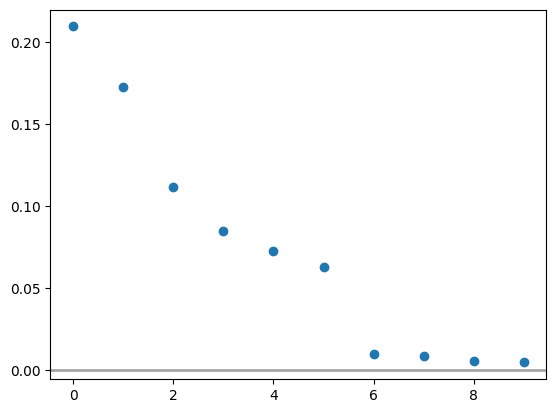

In [6]:
llm_BD = einops.rearrange(llm_BWD, "B W D -> (B W) D")

U, S, Vh = np.linalg.svd(llm_BD, full_matrices=False)

rel_energy = S**2 / (S**2).sum()
plt.scatter(np.arange(10), rel_energy[:10])
plt.axhline(0, color='gray', linewidth=2, alpha=0.7)

In [7]:
np.cumsum(rel_energy)[:25]

array([0.20962021, 0.38222367, 0.49363422, 0.57845896, 0.65095675,
       0.71384764, 0.7236996 , 0.7321749 , 0.737369  , 0.7418756 ,
       0.7456408 , 0.7490417 , 0.75216573, 0.7550702 , 0.75782114,
       0.7603918 , 0.76292086, 0.76532716, 0.7676917 , 0.769953  ,
       0.77215546, 0.77427   , 0.77632993, 0.7783527 , 0.78033245],
      dtype=float32)

In [8]:
top_c = 6

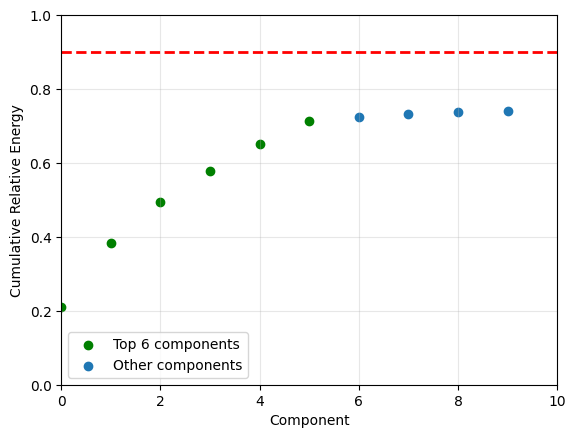

In [9]:
# Plot cumulative sum of relative energy
cumsum_rel_energy = np.cumsum(rel_energy)

# Separate the data into top_c components and the rest
indices = np.arange(len(cumsum_rel_energy[:10]))
plt.scatter(indices[:top_c], cumsum_rel_energy[:top_c], color='green', label=f'Top {top_c} components')
plt.scatter(indices[top_c:], cumsum_rel_energy[top_c:10], label='Other components')

plt.axhline(0.9, color='red', linestyle='--', linewidth=2)
plt.xlim(0, 10)
plt.ylim(0, 1)
plt.xlabel('Component')
plt.ylabel('Cumulative Relative Energy')
# plt.title('Cumulative Sum of Relative Energy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
# WE can't do this before the rotation estimation, that kills the signal.

# r_trunc = 7

# llm_BWD = llm_BWD[..., :r_trunc]

In [11]:
# Get Increment operator
import einops
import numpy as np

batch_arange = np.arange(llm_BWD.shape[0])
weekday_arange = np.arange(llm_BWD.shape[1])
weekday_increment = np.concatenate([weekday_arange[1:], [0]])

X_next_BWD = llm_BWD[batch_arange[:, None], weekday_increment[None, :]]
assert np.allclose(X_next_BWD[0, 6], llm_BWD[0, 0])

X_current_BD = einops.rearrange(llm_BWD, "B W D -> (B W) D")
X_next_BD = einops.rearrange(X_next_BWD, "B W D -> (B W) D")

In [12]:
def plot_complex_ev(evals: np.ndarray, top_c: int = None, axlim=1.4) -> None:

    ax = plt.gca()
    ax.axhline(0, color='gray', linewidth=0.5, alpha=0.7)
    ax.axvline(0, color='gray', linewidth=0.5, alpha=0.7)
    circle = plt.Circle((0, 0), 1, color='gray', fill=False, linewidth=0.5, alpha=0.7)
    ax.add_patch(circle)
    
    if top_c is not None:
        # Plot top_c components in green
        plt.scatter(np.real(evals[:top_c]), np.imag(evals[:top_c]), color='green', label=f'Top {top_c} components', zorder=3)
        # Plot remaining components in default color
        plt.scatter(np.real(evals[top_c:]), np.imag(evals[top_c:]), label='Other components', zorder=2)
        plt.legend()
    else:
        plt.scatter(np.real(evals), np.imag(evals))
    
    plt.xlim(-axlim, axlim)
    plt.ylim(-axlim, axlim)
    plt.xlabel("Real(EV)")
    plt.ylabel("Imag(EV)")
    ax.set_aspect('equal')
    plt.plot()

In [13]:
X_current_BD.shape

(861, 5120)

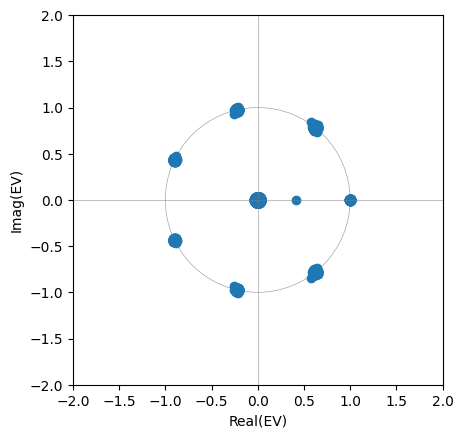

In [14]:
def simple_pinv(X_current_BD, X_next_BD):
    # A_tilde_DD @ X_current_BD.T = X_next_BD.T
    # The operator should be applied from the left, so the eigenvector equation makes sense.
    # A v = \lambda * v
    
    A_tilde_DD =  X_next_BD.T @ np.linalg.pinv(X_current_BD.T)
    evals, evecs = np.linalg.eig(A_tilde_DD)

    return evals, evecs

evals_pinv, evecs_pinv = simple_pinv(X_current_BD, X_next_BD)

plot_complex_ev(evals_pinv, axlim=2)

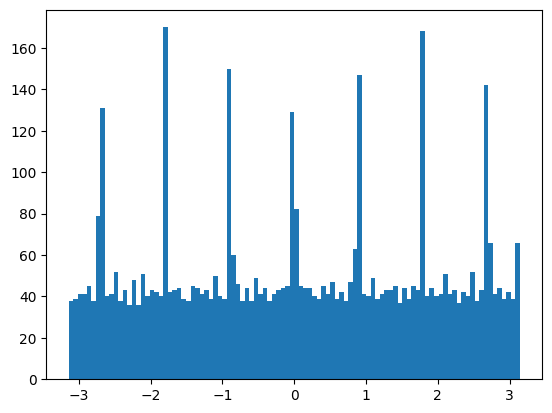

In [15]:
angles = np.angle(evals_pinv)
plt.hist(angles, bins=100);

The DMD approach below estimates the increment operator in the subspace spanned by the data. That's much cleaner, as it removes redundancy, and operating on orthogonal vectors probably is more numerically stable.

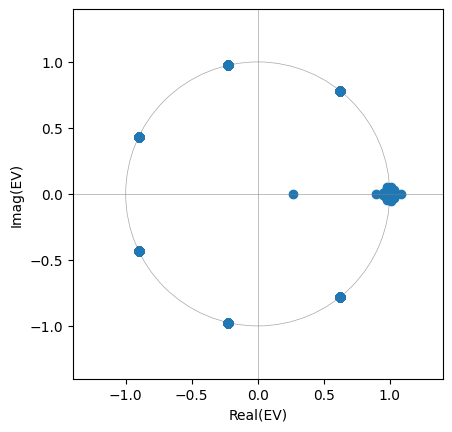

In [16]:
# Note that this is sensitive to r!!! put r > samplesize for no truncation at all.

def dmd(X_current_BD, X_next_BD, r):
    U, S, Vt = np.linalg.svd(X_current_BD, full_matrices=False)

    Ur = U[:, :r]
    Sr = np.diag(S[:r])
    Vr = Vt[:r]

    A_tilde = Ur.T @ X_next_BD @ Vr.T @ np.linalg.inv(Sr)

    evals, evecs = np.linalg.eig(A_tilde)
    modes = Ur @ evecs # columns of evecs are the eigenvectors, so evec[:, 0] is the first eigenvector 

    return evals, evecs, modes

evals, evecs, modes = dmd(X_current_BD, X_next_BD, r=10000)
plot_complex_ev(evals)

In [17]:
np.angle(evals[:10]) * 7 / (2 * np.pi)

array([ 0.        ,  3.5       ,  0.94819707, -0.94819707,  3.5       ,
        0.        ,  0.        ,  0.        ,  0.05575763, -0.05575763],
      dtype=float32)

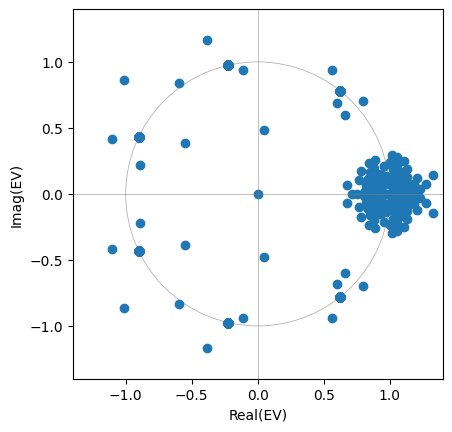

In [18]:
# Note that this is sensitive to r!!! put r > samplesize for no truncation at all.

def dmd(X_current_BD, X_next_BD, r):
    '''
    X = U S Vh = X_current_BD.T
    X_current_BD = Vh.T S U.T
    Y = X_next_BD.T

    Y = A X
    A = Y inv(X)
    A = Y Vh.T inv(S) U.T

    A_tilde = U.T A U
    A_tilde = U.T Y Vh.T inv(s)

    A v = λ v
    U A_tilde U.T v = λ v

    A_tilde v_tilde = λ_tilde v_tilde
    U.T A U v_tilde = λ_tilde v_tilde
    A U v_tilde = λ_tilde U v_tilde

    set v := U v_tilde
    then A (U v_tilde) = λ_tilde (U v_tilde)
    fullfills A v = λ v

    '''
    U, S, Vt = np.linalg.svd(X_current_BD.T, full_matrices=False)
    eigendata_BD = Vt.T
    eigendata_BWD = einops.rearrange(eigendata_BD, "(B W) D -> B W D", W=7)

    Ur = U[:, :r]
    Sr = np.diag(S[:r])
    Vr = Vt[:r]

    A_tilde = Ur.T @ X_next_BD.T @ Vr.T @ np.linalg.inv(Sr)

    evals_C, evecs_DC = np.linalg.eig(A_tilde)
    modes_DC = Ur @ evecs_DC # columns of evecs are the eigenvectors, so evec[:, 0] is the first eigenvector 

    evecs_CD = evecs_DC.T
    modes_CD = modes_DC.T

    return evals_C, evecs_CD, modes_CD, eigendata_BWD

evals_C, evecs_CD, modes_CD, eigendata_BWD = dmd(X_current_BD, X_next_BD, r=10000)
plot_complex_ev(evals_C)

In [19]:
eigendata_BWD.shape
# here

(123, 7, 861)

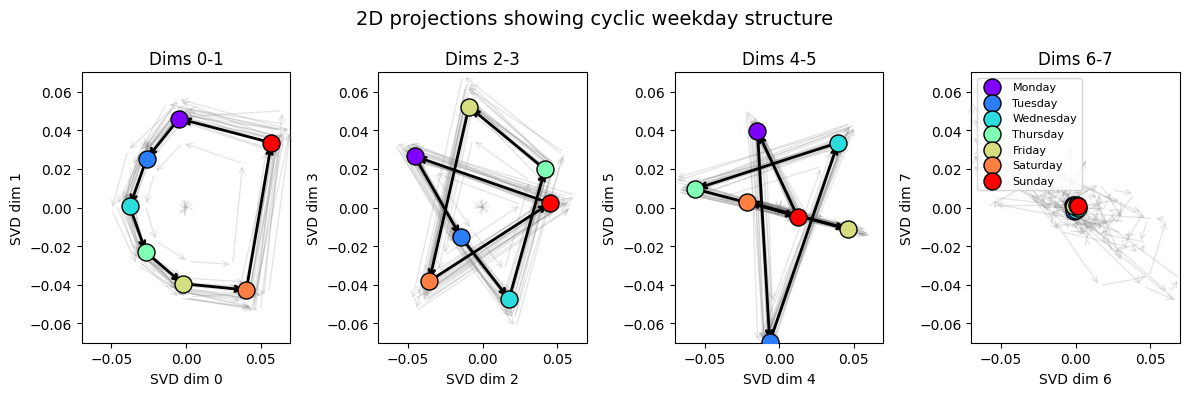

In [20]:
# Also show 2D projections of consecutive SVD dimensions
fig, axes = plt.subplots(1, 4, figsize=(12, 4))
axes = axes.flatten()

dim_pairs = [(0,1), (2,3), (4,5), (6,7)]
weekday_labels = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
colors = np.array([[5.00000000e-01, 0.00000000e+00, 1.00000000e+00, 1.00000000e+00],
       [1.70588235e-01, 4.94655843e-01, 9.66718404e-01, 1.00000000e+00],
       [1.66666667e-01, 8.66025404e-01, 8.66025404e-01, 1.00000000e+00],
       [5.03921569e-01, 9.99981027e-01, 7.04925547e-01, 1.00000000e+00],
       [8.33333333e-01, 8.66025404e-01, 5.00000000e-01, 1.00000000e+00],
       [1.00000000e+00, 4.94655843e-01, 2.55842778e-01, 1.00000000e+00],
       [1.00000000e+00, 1.22464680e-16, 6.12323400e-17, 1.00000000e+00]])

axlim = 0.07

for i, (dim1, dim2) in enumerate(dim_pairs):
    ax = axes[i]
    for b in range(min(20, eigendata_BWD.shape[0])):
        x_coords = eigendata_BWD[b, :, dim1]  # (7,)
        y_coords = eigendata_BWD[b, :, dim2]  # (7,)
        x_coords = np.clip(x_coords, a_min=-axlim, a_max=axlim)
        y_coords = np.clip(y_coords, a_min=-axlim, a_max=axlim)
        # Draw arrows connecting weekdays in order
        for w in range(7):
            next_w = (w + 1) % 7
            ax.annotate('', xy=(x_coords[next_w], y_coords[next_w]),
                       xytext=(x_coords[w], y_coords[w]),
                       arrowprops=dict(arrowstyle='->', alpha=0.2, color='gray'),
                       annotation_clip=True)

    # Plot mean with weekday colors
    mean_x = eigendata_BWD[:, :, dim1].mean(axis=0)  # (7,)
    mean_y = eigendata_BWD[:, :, dim2].mean(axis=0)  # (7,)
    for w in range(7):
        ax.scatter(mean_x[w], mean_y[w], c=[colors[w]], s=150,
                  label=weekday_labels[w], zorder=5, edgecolors='black')
        next_w = (w + 1) % 7
        ax.annotate('', xy=(mean_x[next_w], mean_y[next_w]),
                   xytext=(mean_x[w], mean_y[w]),
                   arrowprops=dict(arrowstyle='->', color='black', lw=2),
                   annotation_clip=True)
    
    ax.set_xlim((-axlim, axlim))
    ax.set_ylim((-axlim, axlim))
    ax.set_xlabel(f'SVD dim {dim1}')
    ax.set_ylabel(f'SVD dim {dim2}')
    ax.set_title(f'Dims {dim1}-{dim2}')
    if i == 3:
        ax.legend(loc='upper left', fontsize=8)

plt.suptitle('2D projections showing cyclic weekday structure', fontsize=14)
plt.tight_layout()
plt.show()

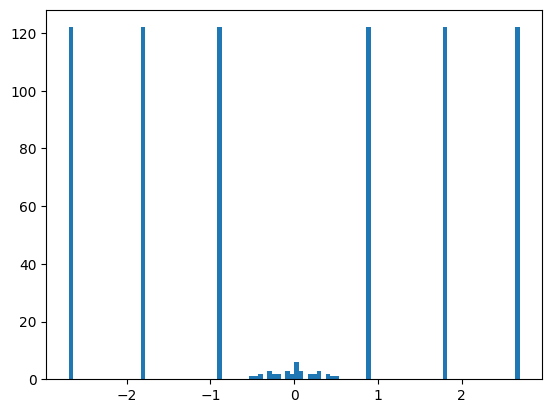

In [19]:
angles = np.angle(evals_C)
plt.hist(angles, bins=100);

In [20]:
0.9 * 2 * np.pi / 7

0.8078381109230897

In [21]:
err = 0.1
freq = 2 * np.pi / 7

# angles_abs = np.abs(angles)
# is_f0 = angles_abs < ((1-err) * freq)
# is_f1 = (angles_abs > ((1-err) * freq)) & (angles_abs < ((1+err) * freq))
# is_f2 = (angles_abs > ((1-err) * 2*freq)) & (angles_abs < ((1+err) * 2*freq))
# is_f3 = angles_abs > ((1+err) * 2*freq)

is_f1 = (angles > ((1-err) * freq)) & (angles < ((1+err) * freq))
is_f2 = (angles > ((1-err) * 2*freq)) & (angles < ((1+err) * 2*freq))
is_f3 = angles > ((1+err) * 2*freq)

In [22]:
sum(is_f1)

np.int64(122)

In [23]:
is_f_nonzero = angles > ((1-err) * freq)

In [24]:
modesX_CD, modesY_CD = np.real(evecs_CD[is_f3]), np.imag(evecs_CD[is_f3])

In [25]:
# Ok we assume the data is cyclic along any of these Eigenvector planes. Let's see if that's the case.
def plot_2d_projection(llm_BWD, x_D, y_D):
    ex_D = x_D / np.linalg.norm(x_D)
    ey_D = y_D - y_D @ x_D * x_D
    ey_D = ey_D / np.linalg.norm(ey_D)


    B, W, D = llm_BWD.shape
    llmX_BW = llm_BWD @ ex_D
    llmY_BW = llm_BWD @ ey_D

    colors = ['r', 'b', 'g', 'y', 'c', 'orange', 'k']
    labels = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    for day_idx in range(W):
        plt.scatter(llmX_BW[: , day_idx], llmY_BW[: , day_idx], c=colors[day_idx], label=labels[day_idx])
    plt.legend(loc="lower right")

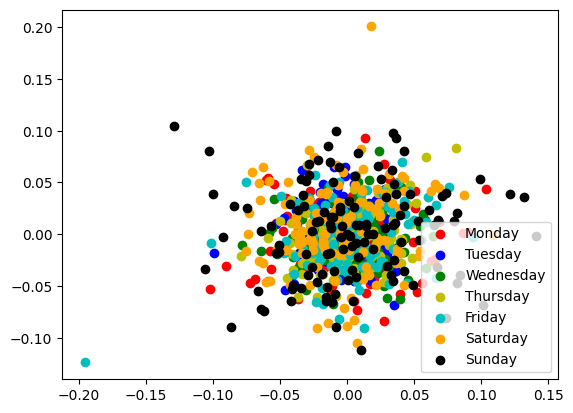

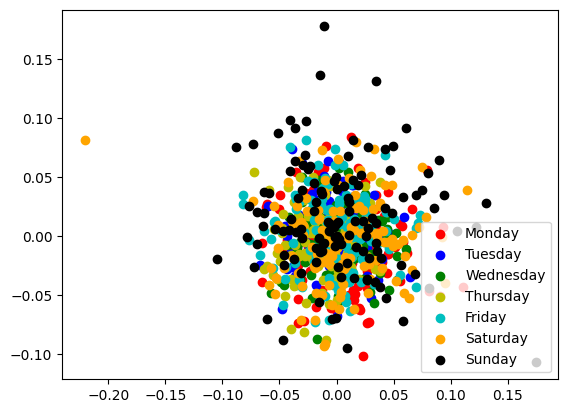

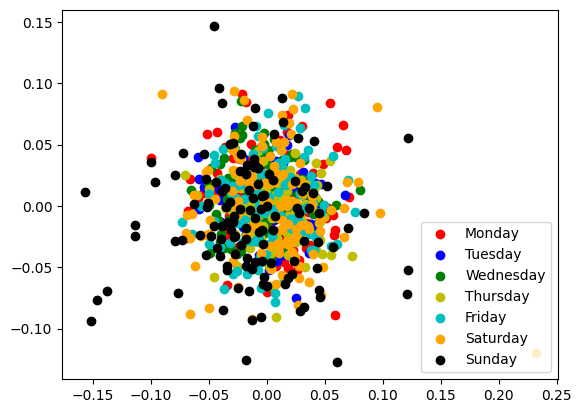

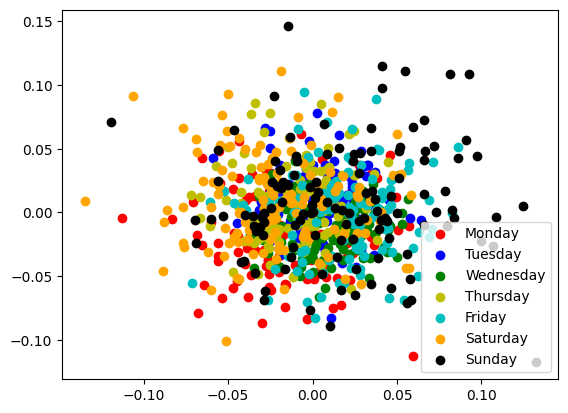

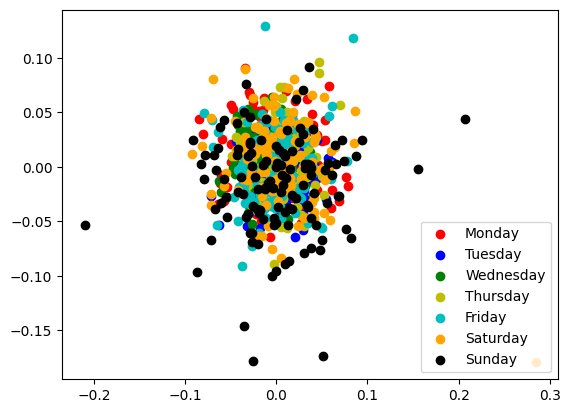

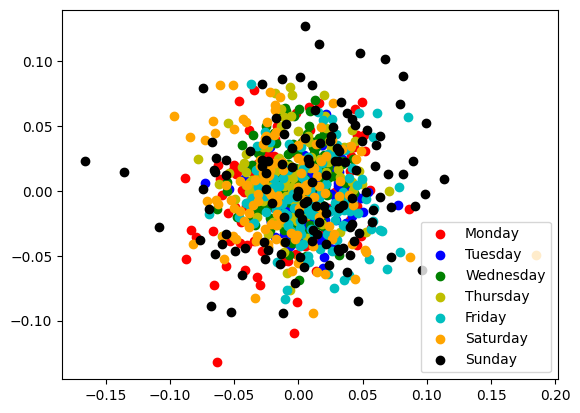

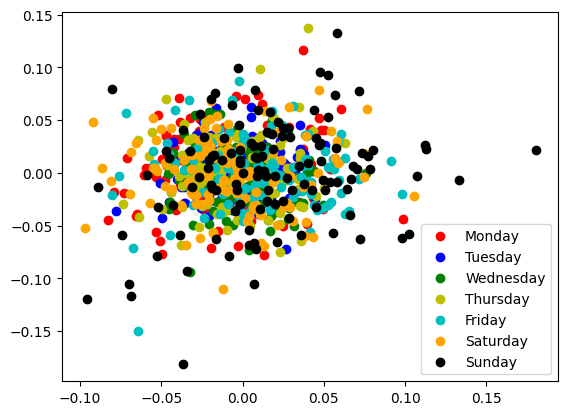

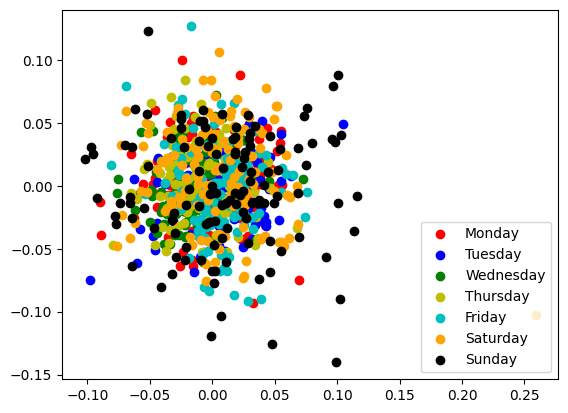

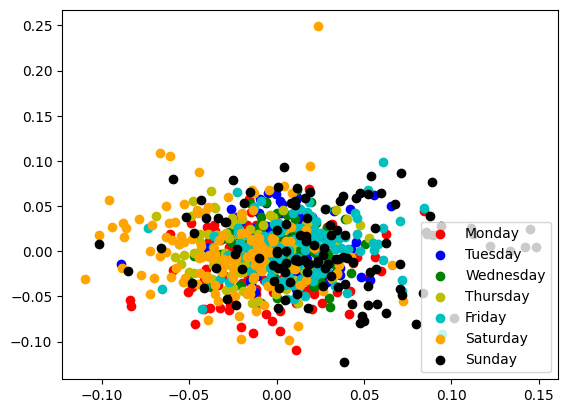

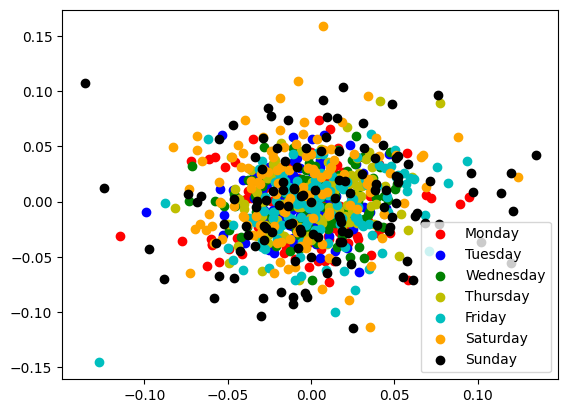

In [26]:
for i in range(10):
    plot_2d_projection(eigendata_BWD, modesX_CD[i], modesY_CD[i])
    plt.show()

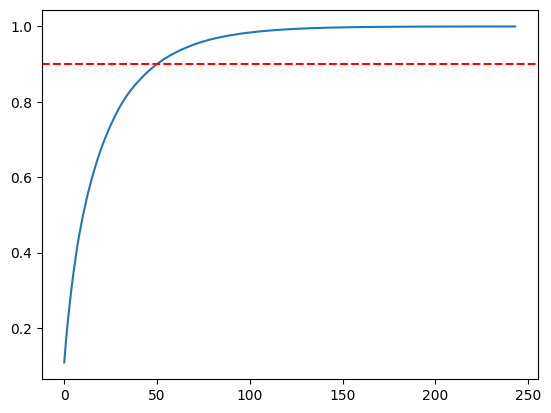

In [ ]:
U, S, Vh = np.linalg.svd(np.concat([modesX_CD, modesY_CD], axis=0), full_matrices=False)
rel_energy = S**2 / np.sum(S**2)
plt.plot(np.cumsum(rel_energy))
plt.axhline(0.9, ls='--', c='red')

In [ ]:
Vh.shape

(244, 768)

In [ ]:
# Let's narrow down on the first 6 EV that together explain 90% of the variance.

evals_C[:6]

array([1.4760283+0.08913232j, 1.4760283-0.08913232j,
       1.3679034+0.23823576j, 1.3679034-0.23823576j,
       1.3564717+0.j        , 1.3239392+0.083758j  ], dtype=complex64)

In [ ]:
np.angle(evals_C[:10]) * 7 / (2 * np.pi)

array([ 0.06719418, -0.06719418,  0.19210352, -0.19210352,  0.        ,
        0.07038791, -0.07038791,  0.44571668, -0.44571668,  0.10131172],
      dtype=float32)

In [ ]:
# It's expected that they're angle  = k / 7 

In [ ]:
is_f0

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

TypeError: Image data of dtype complex64 cannot be converted to float

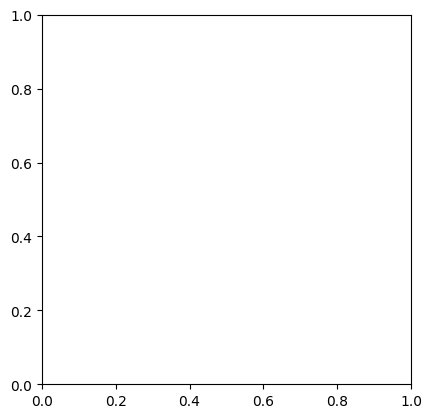

In [ ]:
heat = modes_CD[is_f1] @ modes_CD[is_f2].T
plt.imshow(heat)

In [ ]:
# modes that are only scaled: real EVs
modes_real = modes[is_f0]
modes_real.shape


IndexError: boolean index did not match indexed array along axis 0; size of axis is 861 but size of corresponding boolean axis is 768

In [ ]:
import numpy as np

def weekday_fourier_rank_pca(
    llm_BWD,
    pca_dim=6,
    tol=1e-6,
    return_spectra=False,
):
    """
    PCA-first Fourier analysis of weekday representations.

    Args:
        llm_BWD: np.ndarray, shape (B, 7, D)
        pca_dim: number of PCA dimensions to keep (weekday subspace)
        tol: relative singular value cutoff
        return_spectra: if True, also return singular values

    Returns:
        ranks: dict mapping Fourier mode k -> effective rank
        spectra (optional): dict mapping k -> singular values
    """

    B, W, D = llm_BWD.shape
    assert W == 7, "Expected exactly 7 weekdays"

    # --------------------------------------------------
    # 1. Mean-center over weekday (remove template content)
    # --------------------------------------------------
    X = llm_BWD - llm_BWD.mean(axis=1, keepdims=True)  # (B, 7, D)

    # --------------------------------------------------
    # 2. PCA to extract weekday subspace
    # --------------------------------------------------
    X_flat = X.reshape(-1, D)  # (7B, D)

    U, S, Vt = np.linalg.svd(X_flat, full_matrices=False)
    W_pca = Vt[:pca_dim]  # (pca_dim, D)

    # Project into weekday subspace
    X_proj = X @ W_pca.T  # (B, 7, pca_dim)

    # --------------------------------------------------
    # 3. Fourier analysis in weekday dimension
    # --------------------------------------------------
    ranks = {}
    spectra = {}

    for k in range(W):
        phase = np.exp(-2j * np.pi * k * np.arange(W) / W)
        Xk = np.tensordot(X_proj, phase, axes=(1, 0)) / W  # (B, pca_dim)

        # Stack real & imaginary parts
        Xk_real = np.concatenate([Xk.real, Xk.imag], axis=1)  # (B, 2*pca_dim)

        U_k, S_k, Vt_k = np.linalg.svd(Xk_real, full_matrices=False)

        rank_k = np.sum(S_k > tol * S_k[0])
        ranks[k] = rank_k
        spectra[k] = S_k

    if return_spectra:
        return ranks, spectra, W_pca
    else:
        return ranks

In [ ]:
ranks, spectra, W_pca = weekday_fourier_rank_pca(
    llm_BWD,
    pca_dim=8,      # try 5, 6, 7
    tol=1e-4,
    return_spectra=True,
)

ranks

{0: np.int64(8),
 1: np.int64(16),
 2: np.int64(16),
 3: np.int64(16),
 4: np.int64(16),
 5: np.int64(16),
 6: np.int64(16)}

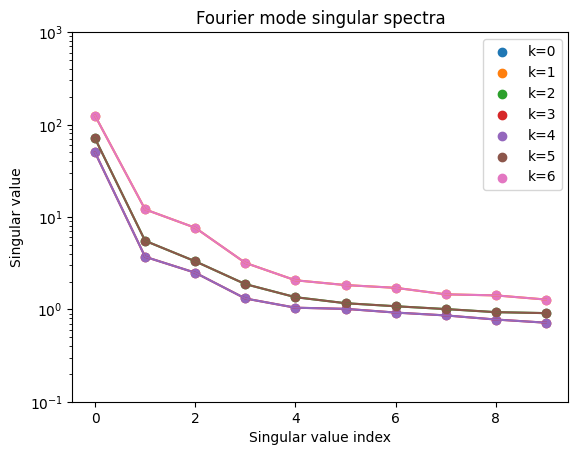

In [ ]:
import matplotlib.pyplot as plt

def plot_fourier_spectra(spectra, max_sv=10):
    for k, S in spectra.items():
        plt.plot(S[:max_sv])
        plt.scatter(np.arange(max_sv), S[:max_sv], label=f"k={k}", lw=1)
    plt.yscale("log")
    plt.xlabel("Singular value index")
    plt.ylabel("Singular value")
    plt.legend()
    plt.ylim(1e-1, 1000)
    plt.title("Fourier mode singular spectra")
    plt.show()

plot_fourier_spectra(spectra)

In [ ]:
spectra

{0: array([5.99744919e-06, 5.27542160e-06, 3.36950767e-06, 2.93351855e-06,
        2.34719373e-06, 1.41423340e-06, 1.07939653e-06, 1.02484263e-06,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00]),
 1: array([124.84349137,  12.06595183,   7.63246028,   3.18314502,
          2.06167531,   1.83030457,   1.70816337,   1.45304852,
          1.41465702,   1.2758662 ,   1.21885226,   1.0260708 ,
          0.97184901,   0.91589599,   0.86590903,   0.66718703]),
 2: array([70.75374943,  5.51617329,  3.30995472,  1.87431645,  1.35325126,
         1.16438622,  1.0798145 ,  1.00634367,  0.93185755,  0.9096055 ,
         0.83768221,  0.80672706,  0.7639676 ,  0.67667781,  0.62271438,
         0.51867663]),
 3: array([49.94736421,  3.70338633,  2.49002134,  1.30967107,  1.04114693,
         1.01141966,  0.92220768,  0.85901612,  0.77540008,  0.71650703,
         0.58112413,  0.5100444 ,  0.49401908,  0.45

In [ ]:
import numpy as np

def extract_weekday_rotation_planes(
    llm_BWD,
    pca_dim=6,
    k_list=(1, 2, 3),
    tol=1e-6,
):
    """
    Extract explicit 2D rotation planes for weekday dynamics.

    Returns:
        planes: dict
            planes[k] = list of (u, v) pairs
            where u, v are orthonormal vectors in original D-dim space
    """

    B, W, D = llm_BWD.shape

    # --------------------------------------------------
    # 1. Mean-center weekday
    # --------------------------------------------------
    X = llm_BWD - llm_BWD.mean(axis=1, keepdims=True)  # (B, 7, D)

    # --------------------------------------------------
    # 2. PCA to weekday subspace
    # --------------------------------------------------
    X_flat = X.reshape(-1, D)
    U, S, Vt = np.linalg.svd(X_flat, full_matrices=False)
    W_pca = Vt[:pca_dim]  # (pca_dim, D)

    X_proj = X @ W_pca.T  # (B, 7, pca_dim)

    planes = {}

    # --------------------------------------------------
    # 3. Fourier modes → SVD → planes
    # --------------------------------------------------
    for k in k_list:
        phase = np.exp(-2j * np.pi * k * np.arange(W) / W)
        Xk = np.tensordot(X_proj, phase, axes=(1, 0)) / W  # (B, pca_dim)

        # Real representation
        Xk_real = np.concatenate([Xk.real, Xk.imag], axis=1)  # (B, 2*pca_dim)

        U_k, S_k, Vt_k = np.linalg.svd(Xk_real, full_matrices=False)

        # Determine effective rank
        r = np.sum(S_k > tol * S_k[0])

        plane_list = []

        i=5

        v = Vt_k[i]              # (2*pca_dim,)
        u_real = v[:pca_dim]
        u_imag = v[pca_dim:]

        # Map back to original D-space
        u = u_real @ W_pca       # (D,)
        w = u_imag @ W_pca       # (D,)

        # Orthonormalize (numerical safety)
        u = u / np.linalg.norm(u)
        w = w - u * np.dot(u, w)
        w = w / np.linalg.norm(w)

        plane_list.append((u, w))
        planes[k] = (u, w)


    return planes

In [ ]:
planes = extract_weekday_rotation_planes(llm_BWD)
planes.keys()

dict_keys([1, 2, 3])

In [ ]:
len(planes[1][0])

768

In [ ]:
def project_onto_plane(llm_BWD, u, w):
    """
    Project weekday data onto a 2D rotation plane.
    Returns shape (B, 7, 2)
    """
    B, W, D = llm_BWD.shape
    X = llm_BWD - llm_BWD.mean(axis=1, keepdims=True)

    proj = np.zeros((B, W, 2))
    proj[..., 0] = np.tensordot(X, u, axes=(2, 0))
    proj[..., 1] = np.tensordot(X, w, axes=(2, 0))

    return proj

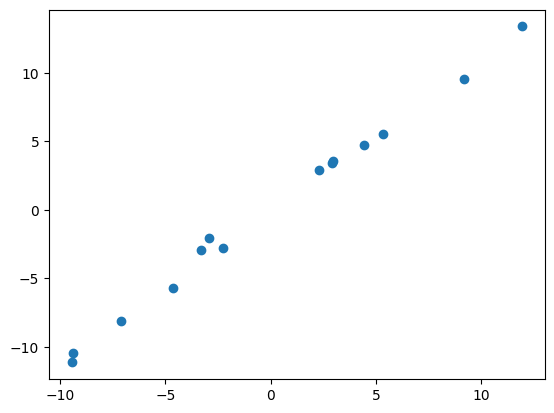

In [ ]:
llm_BWX = project_onto_plane(llm_BWD, u=planes[1][0], w=planes[1][1])
plt.scatter(llm_BWX[0], llm_BWX[1])


In [ ]:
planes[1]

dict_keys([1, 2, 3])